In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# --!--------------------------------------------------------------------------
# --! prepare a dataset

# --! define known data properties
timeseries_len  = 200
timestep        = 2.5e-5
dataset_dir     = 'cavity/train_meas_g'
x_len           = 200 # 40 * 5

# --! read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# --! data channels are expected to contain:
# --! 1. detuning
x_dims_n = 1

# --! compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# --! print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1


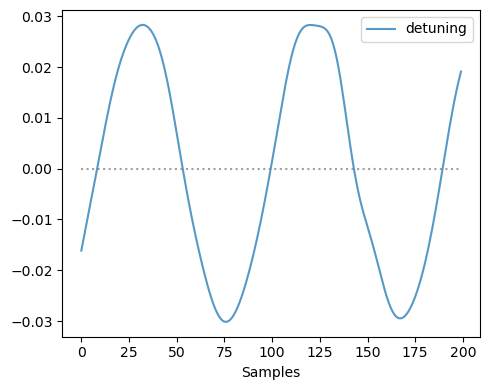

In [3]:
# --!--------------------------------------------------------------------------
# --! visualize individual time series

data_i = 1
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.plot(data_viz[:, 0], color='tab:blue', alpha=0.75, label='detuning')
plt.plot(zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Samples')
plt.tight_layout()
plt.show()

In [4]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

cfg = care.config(

    timeseries_dims_n     = x_dims_n,
    timeseries_sz         = x_len,
    timeseries_timestep   = timestep,

    funs={
        'sin'   : 2,
        'cos'   : 2,
        'data1' : 1,
        'data2' : 1,
    },
    fun_params_kern_sz    = 40,

    fit_weight_lin_global = 1.,
    fit_weight_lin_local  = 0.
)

model = care.detune(cfg)

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


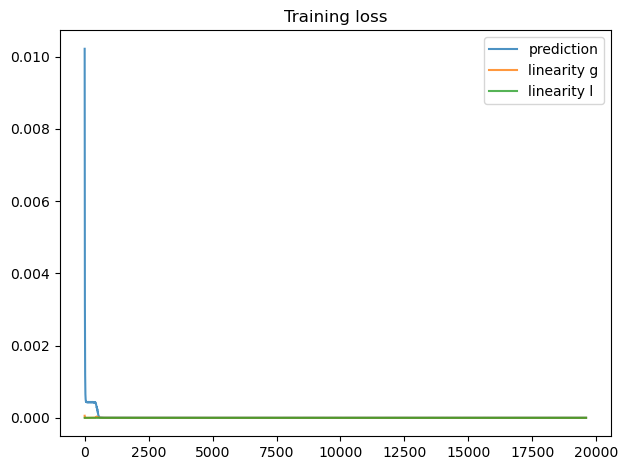

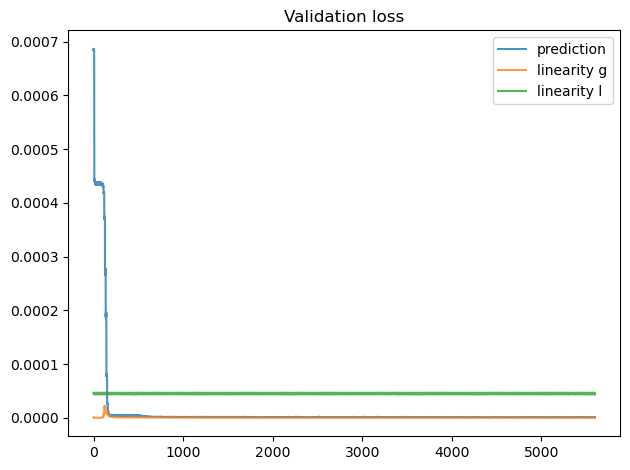

In [5]:
# --!--------------------------------------------------------------------------
# --! training and validation of the global Koopman operator

# --! we train the global operator here, so freeze the local one
utils.unfreeze_module(model.fun_params_kern_enc_g)
utils.freeze_module(model.fun_params_kern_enc_l)

utils.unfreeze_module(model.timeseries_dyn)
utils.freeze_module(model.funs_dyn_enc)
utils.freeze_module(model.funs_dyn)

utils.unfreeze_module(model.dec_g)
utils.freeze_module(model.dec_l)

bat_sz = 128

# --! specify optimizer
optimizer = torch.optim.Adam(
    filter(lambda param: param.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-8)

# --! empty arrays to gather metrics
loss_train_pred  = []
loss_train_lin_g = []
loss_train_lin_l = []
loss_valid_pred  = []
loss_valid_lin_g = []
loss_valid_lin_l = []

# --! training duration
datafiles_train_n = 7
epochs_n          = 100
print(f"inf >> Number of data files for training : {datafiles_train_n}")

# --! prepare validation dataset
dataset_valid = torch.utils.data.TensorDataset(data_valid)

for datafile_train in range(datafiles_train_n):
    print(f"inf >> processing training file number {datafile_train + 1}")

    # --! make training datasets and loaders
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=bat_sz, shuffle=True)

    # --! train
    for epoch in range(epochs_n):

        # --! train neural networks
        for this, data in enumerate(dataloader_train):
            x = data[0][:, :x_len, :1]

            optimizer.zero_grad()

            # --! fit a model to training data
            loss, loss_pred, loss_lin_g, loss_lin_l = model.fit(x, global_only=True)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_pred.append(loss_pred)
                loss_train_lin_g.append(loss_lin_g)
                loss_train_lin_l.append(loss_lin_l)

        # --! validate results
        with torch.no_grad():
            dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=bat_sz, shuffle=False)
            for data in dataloader_valid:
                x  = data[0][:, :x_len, :1] # take only displacement

                # --! validate prediction
                outs = model(x, alpha=1.0)
                funs_g          = outs[0]
                funs_g_pred     = outs[1]
                funs_l          = outs[2]
                funs_l_pred     = outs[3]
                timeseries_pred = outs[4]
                loss_valid_pred.append(torch.mean((x - timeseries_pred)**2))
                loss_valid_lin_g.append(torch.mean((funs_g - funs_g_pred)**2))
                loss_valid_lin_l.append(torch.mean((funs_l - funs_l_pred)**2))

# --!# display training statistics
with torch.no_grad():
    plt.figure()
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_train_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_valid_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
# --!--------------------------------------------------------------------------
# --! gather test metrics

with torch.no_grad():
    # --! make validation datasets and loaders
    dataset_test = torch.utils.data.TensorDataset(data_test)
    dataloader_test = torch.utils.data.DataLoader(dataset_test, batch_size=bat_sz, shuffle=False)

    loss_test_pred = []

    for data in dataloader_test:
        x  = data[0][:, :x_len, :x_dims_n]

        outs = model(x, alpha=1.0)
        funs_g          = outs[0]
        funs_g_pred     = outs[1]
        funs_l          = outs[2]
        funs_l_pred     = outs[3]
        timeseries_pred = outs[4]
        loss_test_pred.append(torch.mean((x - timeseries_pred)**2))

    loss_test_pred_mean = np.mean(loss_test_pred)
    print(f'inf >> prediction loss in test is {loss_test_pred_mean:e}') # 1.481583e-06

inf >> prediction loss in test is 1.481583e-06


tensor([ 1.0004+0.0000j, -0.4607+0.0000j, -0.9286+0.3698j, -0.9286-0.3698j])
tensor([[ 0.4503+0.0000j,  0.2342+0.0000j, -0.0226+0.0005j, -0.0226-0.0005j],
        [ 0.0740+0.0000j,  0.5846+0.0000j, -0.1592-0.5068j, -0.1592+0.5068j],
        [ 0.7175+0.0000j, -0.7739+0.0000j, -0.6187+0.0000j, -0.6187-0.0000j],
        [ 0.5262+0.0000j,  0.0667+0.0000j,  0.2790-0.5066j,  0.2790+0.5066j]])


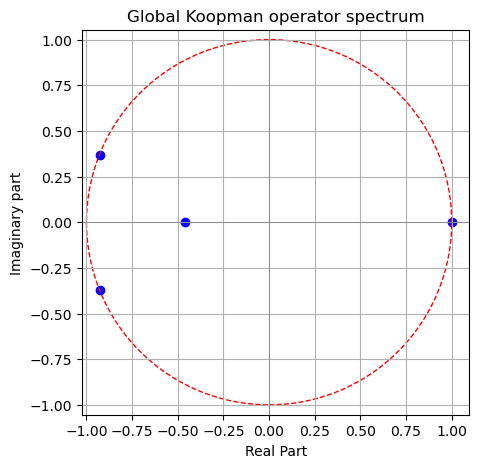

In [7]:
# --!--------------------------------------------------------------------------
# --! visualize global operator eigenvalues

save_eigvals = False

with torch.no_grad():
    eigvals, eigvecs = torch.linalg.eig(model.timeseries_dyn.weight)
    print(eigvals)
    print(eigvecs)

    reals = eigvals.real.view(-1, 1)
    imags = eigvals.imag.view(-1, 1)

    plt.figure(figsize=(5, 5))
    plt.scatter(reals[:, 0], imags[:, 0], c='blue')
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    circle = plt.Circle((0, 0), 1, color='r', fill=False, linestyle='--')
    plt.gca().add_artist(circle)
    plt.title("Global Koopman operator spectrum")
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary part")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

    if save_eigvals:
        eigvals = np.expand_dims(np.concatenate([reals, imags], axis=1), 0)
        utils.write_datafile('global_eigvals_meas', eigvals, delim=' ')

tensor([[9.6072e-04],
        [3.8086e-05],
        [1.2151e-02],
        [1.2151e-02]])
[[1.]
 [2.]
 [3.]
 [4.]]


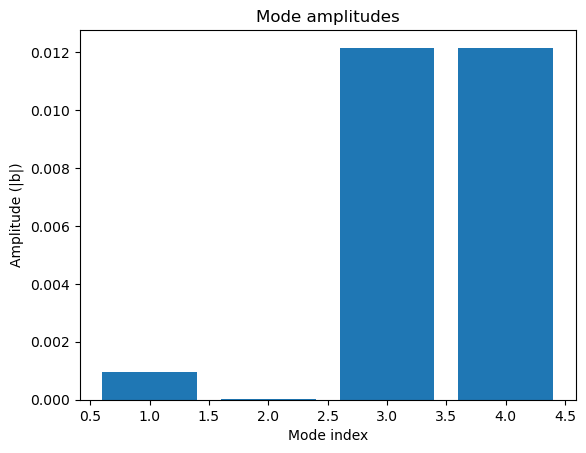

In [8]:
# --!--------------------------------------------------------------------------
# --! analyze the amplitude of global operator eigenvalues

save_eigamps = False

with torch.no_grad():
    data_i      = 1
    data_ic     = torch.unsqueeze(data_test[data_i][:model.fun_params_kern_sz, :1], 0)
    funs_ic     = model._embed_functions_g(data_ic)
    eigvecs_inv = torch.linalg.inv(eigvecs)
    funs_ic     = torch.squeeze(funs_ic, 0)
    eigvecs_inv = torch.squeeze(eigvecs_inv, 0)
    funs_ic     = funs_ic.to(torch.cfloat)
    b = torch.matmul(eigvecs_inv, torch.transpose(funs_ic, 0, 1))
    b = b.abs()
    b_nums = np.array([range(len(b[:, 0]))]).reshape(-1, 1) + 1.0
    print(b)
    print(b_nums)

    plt.figure()
    plt.bar(b_nums[:, 0], b[:, 0])
    plt.title("Mode amplitudes")
    plt.xlabel("Mode index")
    plt.ylabel("Amplitude (|b|)")
    plt.show()

    if save_eigamps:
        eigamps = np.expand_dims(np.concatenate([b_nums, b], axis=1), 0)
        utils.write_datafile(f'global_eigamps_{data_i}_meas', eigamps, delim=' ')

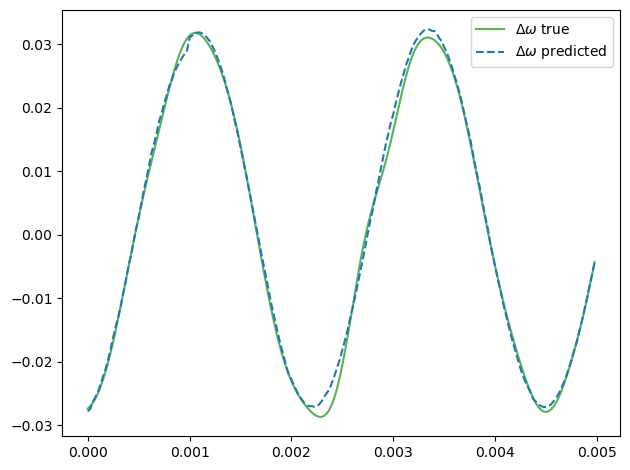

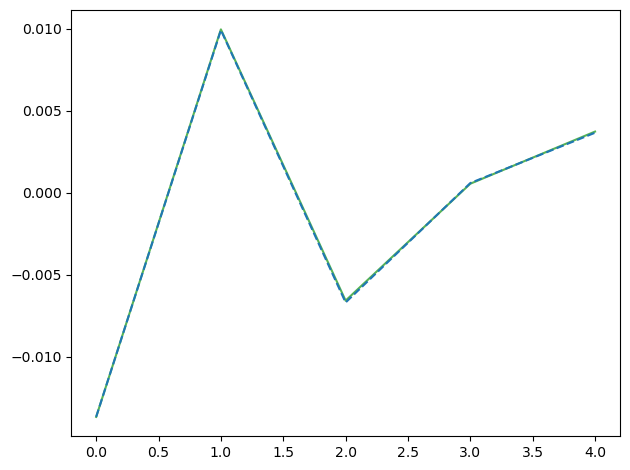

In [9]:
# --!--------------------------------------------------------------------------
# --! test individual results

save_sigs = False

with torch.no_grad():
    data_i  = 1
    data    = data_test[data_i]

    timeseries = torch.unsqueeze(data[:x_len, :1], dim=0)
    outs = model(timeseries, alpha=1.0)
    funs_g          = outs[0]
    funs_g_pred     = outs[1]
    funs_l          = outs[2]
    funs_l_pred     = outs[3]
    timeseries_pred = outs[4]

    timeseries = torch.squeeze(timeseries, dim=0)
    timeseries_pred = torch.squeeze(timeseries_pred, dim=0)

    t = np.arange(0., x_len*timestep, timestep).reshape(-1, 1)

    plt.figure()
    plt.plot(t[:, 0], timeseries[:, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
    plt.plot(t[:, 0], timeseries_pred[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ predicted')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(funs_g[0, :, 3], alpha=0.8, color='tab:green')
    plt.plot(funs_g_pred[0, :, 3], alpha=1, color='tab:blue', linestyle='dashed')
    plt.tight_layout()
    plt.show()

    if save_sigs:
        sigs = np.expand_dims(np.concatenate([t, timeseries, timeseries_pred], axis=1), 0)
        utils.write_datafile(f'global_sig_{data_i}', sigs, delim=' ')

In [10]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = False
print(model.timeseries_dyn.weight)

if savemod_on:
    torch.save(model, 'data/models/care_global_meas.pt')

Parameter containing:
tensor([[ 0.5196, -0.2487,  0.1318,  0.2667],
        [ 0.4932, -0.9824, -0.2301,  0.1705],
        [ 1.1929, -0.5135, -0.4042,  0.9664],
        [ 1.7702, -0.6797,  0.0232, -0.4505]], requires_grad=True)


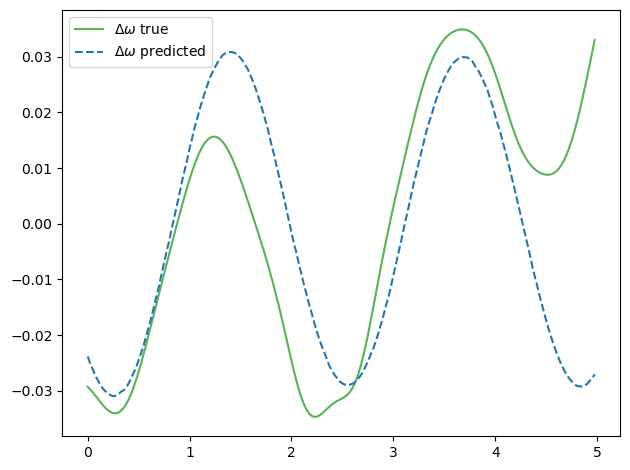

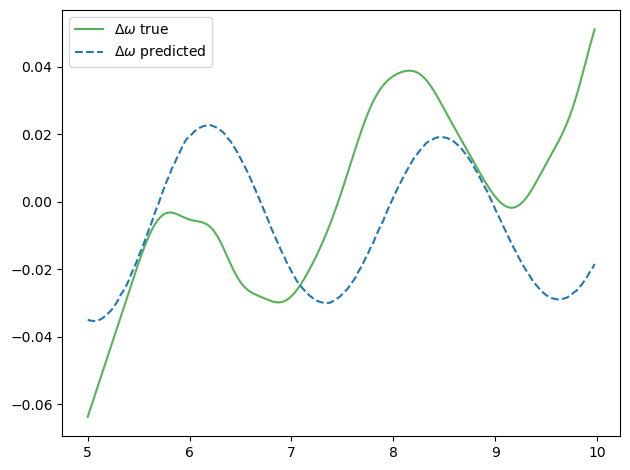

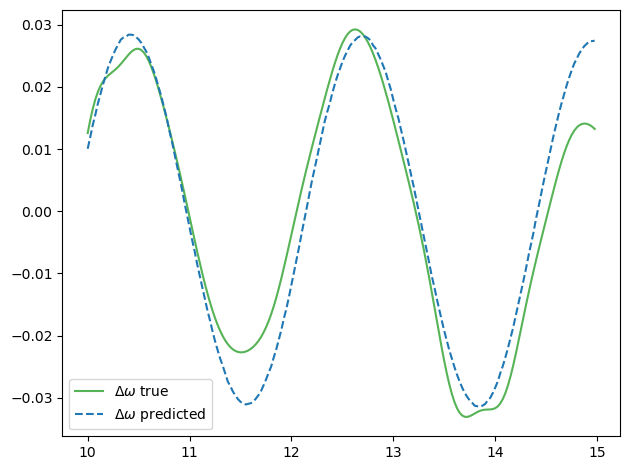

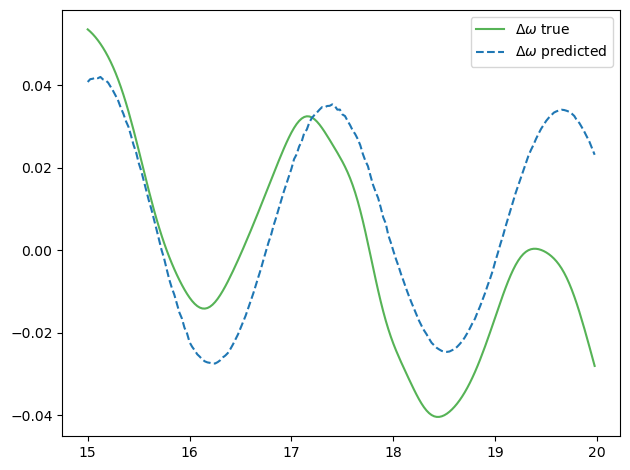

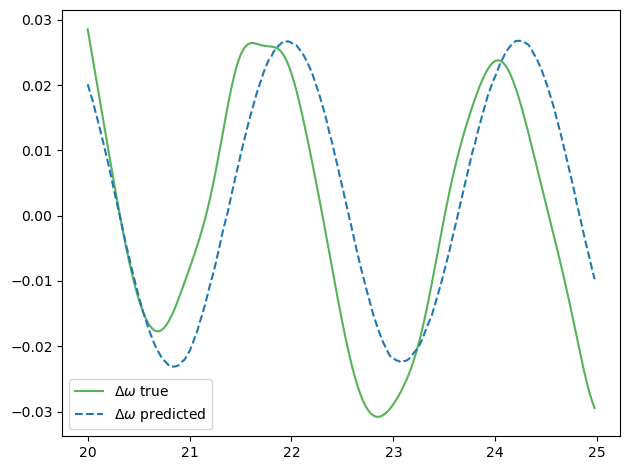

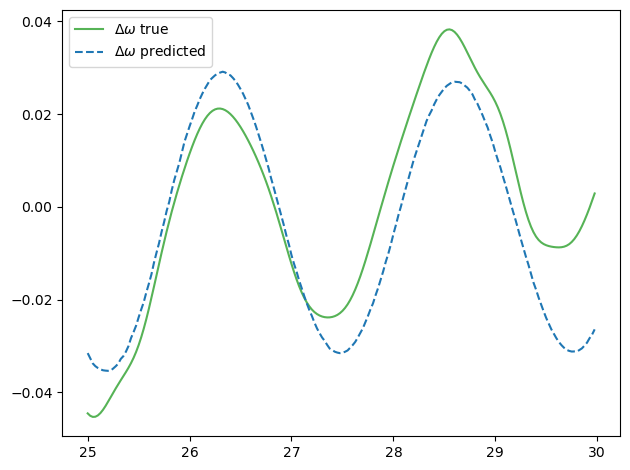

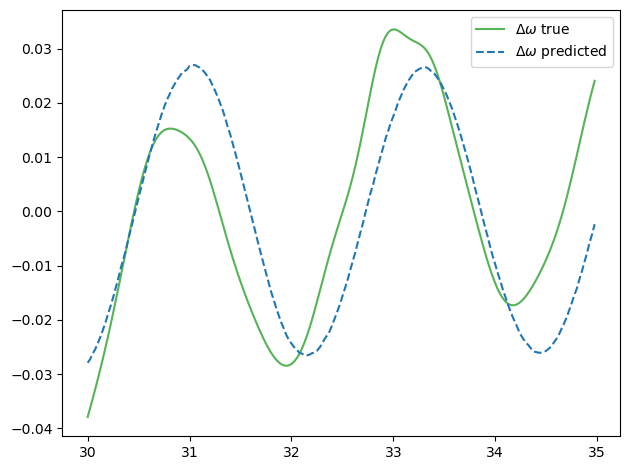

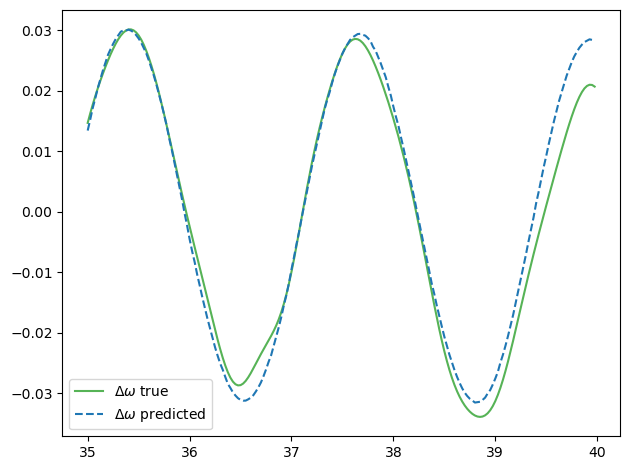

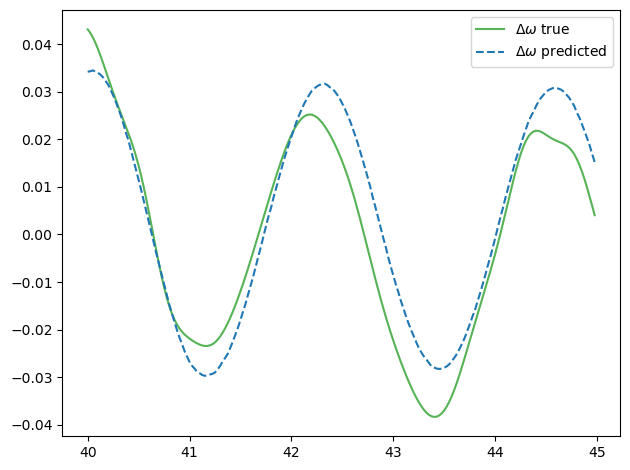

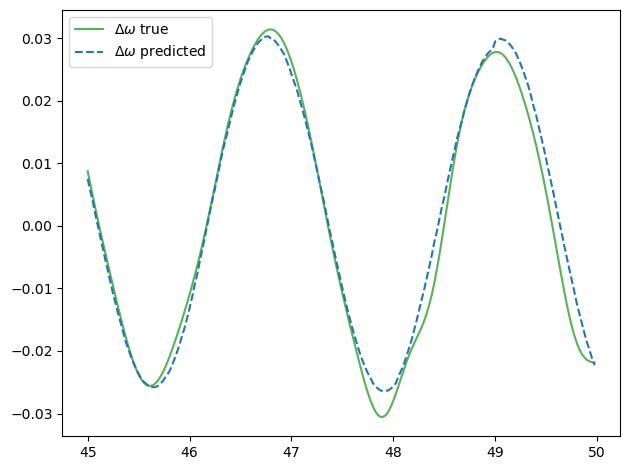

inf >> prediction loss in evaluation is 2.050894e-04


In [11]:
# --!--------------------------------------------------------------------------
# --! evaluate model

eval_ts_len       = 200
eval_timestep     = 2.5e-5
eval_dataset_dir  = 'cavity/eval_meas'

eval_data = utils.read_datafile(f'{eval_dataset_dir}/eval1', eval_ts_len)

save_sigs_trans = True

loss_eval_pred  = []

with torch.no_grad():
    data = torch.split(eval_data, 1, dim=0)
    for this, datum in enumerate(data):
        datum = datum[:, :x_len, :1]

        outs = model(datum, alpha=1.0)
        funs_g          = outs[0]
        funs_g_pred     = outs[1]
        funs_l          = outs[2]
        funs_l_pred     = outs[3]
        timeseries_pred = outs[4]

        timeseries = torch.squeeze(datum, dim=0)
        timeseries_pred = torch.squeeze(timeseries_pred, dim=0)

        # compute losses for metrics
        loss_eval_pred.append(torch.mean((timeseries - timeseries_pred)**2))

        t = np.arange(0., eval_ts_len*eval_timestep, eval_timestep).reshape(-1, 1) * 1e3
        t = t + this*5

        plt.figure()
        plt.plot(t[:x_len, 0], timeseries[:x_len, 0], alpha=0.8, color='tab:green', label='$\\Delta \\omega$ true')
        plt.plot(t[:x_len, 0], timeseries_pred[:, 0], alpha=1, color='tab:blue', linestyle='dashed', label='$\\Delta \\omega$ predicted')
        plt.legend()
        plt.tight_layout()
        plt.show()

        if save_sigs_trans:
            sig_trans = np.expand_dims(np.concatenate([t[:x_len, :1], timeseries, timeseries_pred], axis=1), 0)
            utils.write_datafile(f'global_sig_trans_meas_{this}', sig_trans, delim=' ')

    loss_eval_pred_mean = np.mean(loss_eval_pred)
    print(f'inf >> prediction loss in evaluation is {loss_eval_pred_mean:e}')